# Light Leak Analysis

We investigate the nature of the light leak here with the following data sets: 

1) Observations taken on 26-02-16 with the array blanked off
2) Obseravtions taken on 26-02-03 with of the sky and the CVF set to "blocking"

In [1]:
# Import all the necessary libraries
%run install_packages.py
import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry 
from test_analysis import read_in_fits
from analysis_functions import * 

MIRSI Simulations - Package Dependency Checker

Checking for required packages...
✓ numpy is already installed
✓ astropy is already installed
✓ matplotlib is already installed
✓ photutils is already installed
✓ scipy is already installed

✓ All required packages are already installed!

Setup complete! You can now run the MIRSI simulations.


Here, we take the data from the sky at zenith, the blocking fitler in at zenith, the 

In [2]:
# Import data

# Array temp for the data set was 6.2K
zenith_sky_1_data = read_in_fits('./data/260203/zenith_sky_1')
zenith_blanked_sky_data = read_in_fits('./data/260203/zenith_dark')
HAM_blanked_sky_data = read_in_fits('./data/260203/highAM_dark')

# Take the warmest data sets since you'd expect the most noise from those. (Data sets 4 and 5 at 9.0 and 8.5 K respectively)
dark_4_data = read_in_fits('./data/260216/dark4')
dark_5_data = read_in_fits('./data/260216/dark5')

# But the array at dark 1 is comparable to the array temp at the telescope the night the data was taken so we'll also analyze that data set.
dark_1_data = read_in_fits('./data/260216/dark1')


Processing 1500 FITS files from ./data/260203/zenith_sky_1
Loaded 1500 FITS files from ./data/260203/zenith_sky_1
Processing 1500 FITS files from ./data/260203/zenith_dark
Loaded 1500 FITS files from ./data/260203/zenith_dark
Processing 1500 FITS files from ./data/260203/highAM_dark
Loaded 1500 FITS files from ./data/260203/highAM_dark
Processing 1500 FITS files from ./data/260216/dark4
Loaded 1500 FITS files from ./data/260216/dark4
Processing 1500 FITS files from ./data/260216/dark5
Loaded 1500 FITS files from ./data/260216/dark5
Processing 1500 FITS files from ./data/260216/dark1
Loaded 1500 FITS files from ./data/260216/dark1


From prior work we know that that the values start to settle around frame 200. 

In [3]:
TRIM_FRAMES = (199,-1)

COADDS = np.arange(5,251)

## Check the frequency content 

In [4]:
zenith_sky_data_channels = extract_channels(zenith_sky_1_data, channel_width=20, trim=TRIM_FRAMES)
zenith_sky_variances, zenith_sky_t_dwell, zenith_sky_f_state, zenith_sky_f_coadd = create_variance_curve(zenith_sky_data_channels["channels"], COADDS, frame_dt_s=0.0103)

zenith_blanked_sky_data_channels = extract_channels(zenith_blanked_sky_data, channel_width=20, trim=TRIM_FRAMES)
zenith_blanked_sky_variances, zenith_blanked_sky_t_dwell, zenith_blanked_sky_f_state, zenith_blanked_sky_f_coadd = create_variance_curve(zenith_blanked_sky_data_channels["channels"], COADDS, frame_dt_s=0.0103)

dark_1_data_channels = extract_channels(dark_1_data, channel_width=20, trim=TRIM_FRAMES)
dark_1_variances, dark_1_t_dwell, dark_1_f_state, dark_1_f_coadd = create_variance_curve(dark_1_data_channels["channels"], COADDS, frame_dt_s=0.0113)

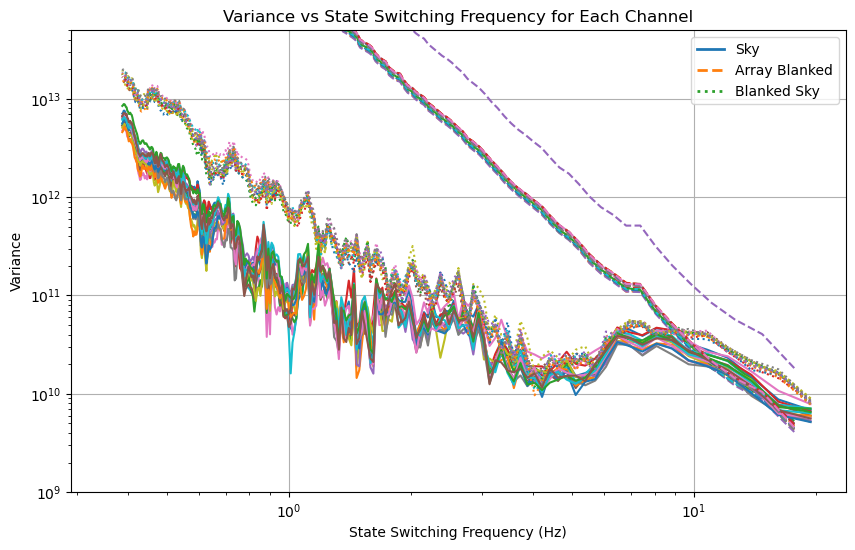

In [5]:
from matplotlib.lines import Line2D

plt.figure(figsize=(10, 6))
for channel in range(zenith_sky_data_channels["channels"].shape[0]): 
    variances_ch = [zenith_sky_variances[n][channel] for n in range(len(COADDS))]
    variances_dark_ch = [dark_1_variances[n][channel] for n in range(len(COADDS))]
    variances_blanked_ch = [zenith_blanked_sky_variances[n][channel] for n in range(len(COADDS))]
    plt.plot(zenith_sky_f_state, variances_ch)
    plt.plot(dark_1_f_state, variances_dark_ch, ls='--')
    plt.plot(zenith_blanked_sky_f_state, variances_blanked_ch, ls=':')

plt.xlabel('State Switching Frequency (Hz)')
plt.ylabel('Variance')
plt.title('Variance vs State Switching Frequency for Each Channel')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e9, 5e13)

# Create legend with just line styles
legend_elements = [Line2D([0], [0], color='C0', lw=2, label='Sky'),
                   Line2D([0], [0], color='C1', lw=2, linestyle='--', label='Array Blanked'),
                   Line2D([0], [0], color='C2', lw=2, linestyle=':', label='Blanked Sky')]
plt.legend(handles=legend_elements)
plt.grid()
plt.show()

Seperate the plots into subplots

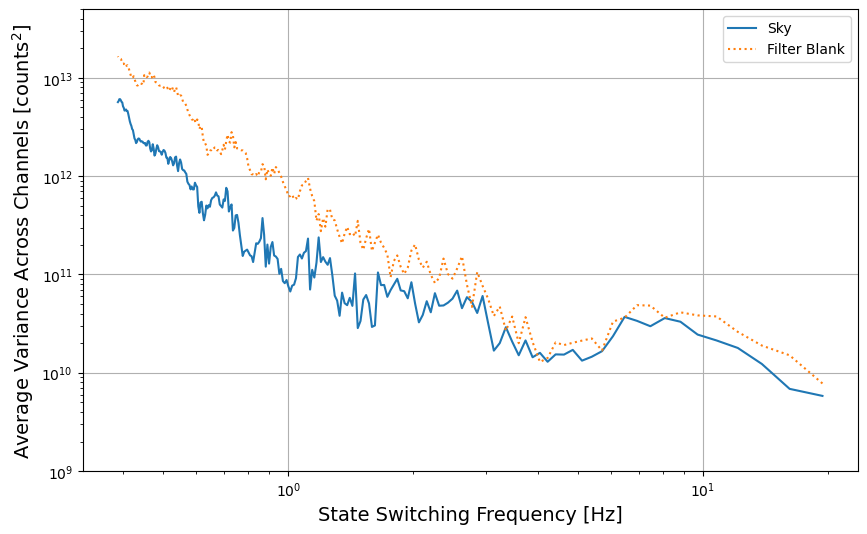

In [6]:
# find the average of the variances across all channels for each data set and plot those as well
avg_variances_sky = [np.mean([zenith_sky_variances[n][channel] for channel in range(zenith_sky_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]
#avg_variances_dark = [np.mean([dark_1_variances[n][channel] for channel in range(dark_1_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_blanked = [np.mean([zenith_blanked_sky_variances[n][channel] for channel in range(zenith_blanked_sky_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]
plt.figure(figsize=(10, 6))
plt.plot(zenith_sky_f_state, avg_variances_sky, label='Sky')
#plt.plot(dark_1_f_state, avg_variances_dark, ls='--', label='Array Blanked')
plt.plot(zenith_blanked_sky_f_state, avg_variances_blanked, ls=':', label='Filter Blank')
plt.xlabel('State Switching Frequency [Hz]', fontsize=14)
plt.ylabel(r'Average Variance Across Channels [counts$^2$]', fontsize=14)
#plt.title('Average Variance vs State Switching Frequency')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e9, 5e13)
plt.legend()
plt.grid()

# Optional: save fig 
plt.savefig('./figures/sky_vs_filter_blank.png', dpi=600, bbox_inches='tight')
plt.show()

In [7]:
# Now plot the detector blanked data on the same plot as the sky and filter blanked data to see if it matches either of those.
#average over all channels 

Make a plot fo just Dark 1 for John 

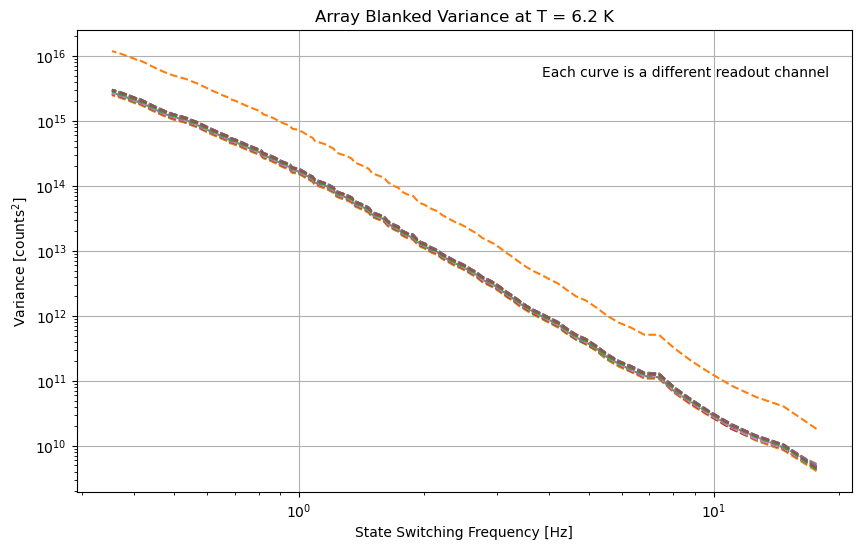

In [8]:
# Plot of just dark 1 
plt.figure(figsize=(10, 6))
for channel in range(dark_1_data_channels["channels"].shape[0]):
    variances_dark_ch = [dark_1_variances[n][channel] for n in range(len(COADDS))]
    plt.plot(dark_1_f_state, variances_dark_ch, ls='--')
plt.xlabel('State Switching Frequency [Hz]')
plt.ylabel(r'Variance [counts$^2$]')
plt.title('Array Blanked Variance at T = 6.2 K')
plt.xscale('log')
plt.yscale('log')
#plt.ylim(1e9, 5e13)
plt.text(0.6, 0.9, 'Each curve is a different readout channel', transform=plt.gca().transAxes)
plt.grid()
plt.show()
# add text saying each curve is a different channel 


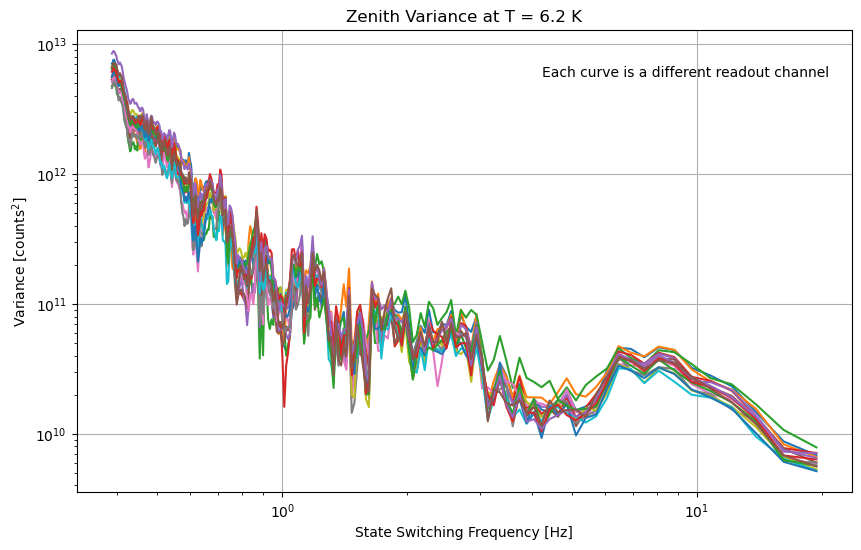

In [9]:
# Now plot zenith sky 1 
plt.figure(figsize=(10, 6))
for channel in range(zenith_sky_data_channels["channels"].shape[0]):
    variances_ch = [zenith_sky_variances[n][channel] for n in range(len(COADDS))]
    plt.plot(zenith_sky_f_state, variances_ch)
plt.xlabel('State Switching Frequency [Hz]')
plt.ylabel(r'Variance [counts$^2$]')
plt.title('Zenith Variance at T = 6.2 K')
plt.xscale('log')
plt.yscale('log')
#plt.ylim(1e9, 5e13)
plt.text(0.6, 0.9, 'Each curve is a different readout channel', transform=plt.gca().transAxes)
plt.grid()
plt.show()

This plot computes the variance as a function of the state switching frequency. For the most comparable array temperatures the red noise of the detector is evident here.

Now, take the worst case, where the array is the warmest and we'd expect the most red noise. 

In [10]:
dark_2_data = read_in_fits('./data/260216/dark2')
dark_3_data = read_in_fits('./data/260216/dark3')
dark_6_data = read_in_fits('./data/260216/dark6')
dark_7_data = read_in_fits('./data/260216/dark7')
dark_8_data = read_in_fits('./data/260216/dark8')

dark_1_data_channels = extract_channels(dark_1_data, channel_width=20, trim=TRIM_FRAMES)
dark_1_variances, dark_1_t_dwell, dark_1_f_state, dark_1_f_coadd = create_variance_curve(dark_1_data_channels["channels"], COADDS, frame_dt_s=0.0113)
dark_2_data_channels = extract_channels(dark_2_data, channel_width=20, trim=TRIM_FRAMES)
dark_2_variances, dark_2_t_dwell, dark_2_f_state, dark_2_f_coadd = create_variance_curve(dark_2_data_channels["channels"], COADDS, frame_dt_s=0.0113)
dark_3_data_channels = extract_channels(dark_3_data, channel_width=20, trim=TRIM_FRAMES)
dark_3_variances, dark_3_t_dwell, dark_3_f_state, dark_3_f_coadd = create_variance_curve(dark_3_data_channels["channels"], COADDS, frame_dt_s=0.0113)
dark_4_data_channels = extract_channels(dark_4_data, channel_width=20, trim=TRIM_FRAMES)
dark_4_variances, dark_4_t_dwell, dark_4_f_state, dark_4_f_coadd = create_variance_curve(dark_4_data_channels["channels"], COADDS, frame_dt_s=0.0113)
dark_5_data_channels = extract_channels(dark_5_data, channel_width=20, trim=TRIM_FRAMES)
dark_5_variances, dark_5_t_dwell, dark_5_f_state, dark_5_f_coadd = create_variance_curve(dark_5_data_channels["channels"], COADDS, frame_dt_s=0.0113)
dark_6_data_channels = extract_channels(dark_6_data, channel_width=20, trim=TRIM_FRAMES)
dark_6_variances, dark_6_t_dwell, dark_6_f_state, dark_6_f_coadd = create_variance_curve(dark_6_data_channels["channels"], COADDS, frame_dt_s=0.0113)
dark_7_data_channels = extract_channels(dark_7_data, channel_width=20, trim=TRIM_FRAMES)
dark_7_variances, dark_7_t_dwell, dark_7_f_state, dark_7_f_coadd = create_variance_curve(dark_7_data_channels["channels"], COADDS, frame_dt_s=0.0113)
dark_8_data_channels = extract_channels(dark_8_data, channel_width=20, trim=TRIM_FRAMES)
dark_8_variances, dark_8_t_dwell, dark_8_f_state, dark_8_f_coadd = create_variance_curve(dark_8_data_channels["channels"], COADDS, frame_dt_s=0.0113)

Processing 1500 FITS files from ./data/260216/dark2
Loaded 1500 FITS files from ./data/260216/dark2
Processing 1500 FITS files from ./data/260216/dark3
Loaded 1500 FITS files from ./data/260216/dark3
Processing 1500 FITS files from ./data/260216/dark6
Loaded 1500 FITS files from ./data/260216/dark6
Processing 1500 FITS files from ./data/260216/dark7
Loaded 1500 FITS files from ./data/260216/dark7
Processing 1500 FITS files from ./data/260216/dark8
Loaded 1500 FITS files from ./data/260216/dark8


In [11]:
# Now plot the averages for each of the dark data 
avg_variances_dark_1 = [np.median([dark_1_variances[n][channel] for channel in range(dark_1_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_2 = [np.median([dark_2_variances[n][channel] for channel in range(dark_2_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_3 = [np.median([dark_3_variances[n][channel] for channel in range(dark_3_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_4 = [np.median([dark_4_variances[n][channel] for channel in range(dark_4_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_5 = [np.median([dark_5_variances[n][channel] for channel in range(dark_5_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_6 = [np.median([dark_6_variances[n][channel] for channel in range(dark_6_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_7 = [np.median([dark_7_variances[n][channel] for channel in range(dark_7_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_8 = [np.median([dark_8_variances[n][channel] for channel in range(dark_8_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]

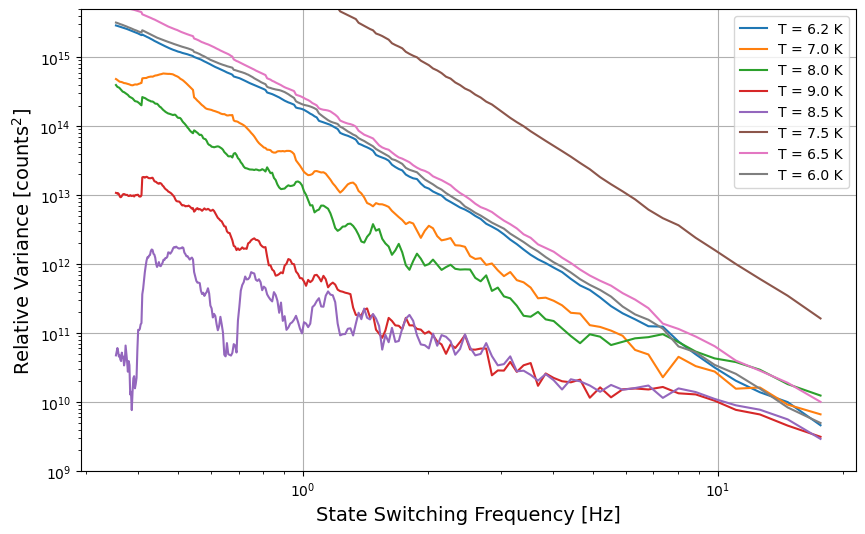

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(dark_1_f_state, avg_variances_dark_1, label='T = 6.2 K')
plt.plot(dark_2_f_state, avg_variances_dark_2, label='T = 7.0 K')
plt.plot(dark_3_f_state, avg_variances_dark_3, label='T = 8.0 K')
plt.plot(dark_4_f_state, avg_variances_dark_4, label='T = 9.0 K')
plt.plot(dark_5_f_state, avg_variances_dark_5, label='T = 8.5 K')
plt.plot(dark_6_f_state, avg_variances_dark_6, label='T = 7.5 K')
plt.plot(dark_7_f_state, avg_variances_dark_7, label='T = 6.5 K')
plt.plot(dark_8_f_state, avg_variances_dark_8, label='T = 6.0 K')
plt.xlabel('State Switching Frequency [Hz]', fontsize=14)
plt.ylabel(r'Relative Variance [counts$^2$]', fontsize=14)
#plt.title('Average Variance vs State Switching Frequency for Dark Data Sets')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e9, 5e15)
plt.legend()
plt.grid()

# Optional: save fig
plt.savefig('./figures/dark_data_variances.png', dpi=600, bbox_inches='tight')
plt.show()

In [13]:
avg_variances_sky = [np.mean([zenith_sky_variances[n][channel] for channel in range(zenith_sky_data_channels["channels"].shape[0])]) for n in range(len(COADDS))]

In [14]:
# Now plot the averages for each of the dark data 
avg_variances_dark_1 = [np.mean([dark_1_variances[n][channel] for channel in range(dark_1_variances["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_2 = [np.mean([dark_2_variances[n][channel] for channel in range(dark_2_variances["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_3 = [np.mean([dark_3_variances[n][channel] for channel in range(dark_3_variances["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_4 = [np.mean([dark_4_variances[n][channel] for channel in range(dark_4_variances["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_5 = [np.mean([dark_5_variances[n][channel] for channel in range(dark_5_variances["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_6 = [np.mean([dark_6_variances[n][channel] for channel in range(dark_6_variances["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_7 = [np.mean([dark_7_variances[n][channel] for channel in range(dark_7_variances["channels"].shape[0])]) for n in range(len(COADDS))]
avg_variances_dark_8 = [np.mean([dark_8_variances[n][channel] for channel in range(dark_8_variances["channels"].shape[0])]) for n in range(len(COADDS))]

TypeError: list indices must be integers or slices, not str

In [ ]:
# Plot the high airmass data against the zenith data 
highAM_data_channels = extract_channels(HAM_blanked_sky_data, channel_width=20, trim=TRIM_FRAMES)
highAM_variances, highAM_t_dwell, highAM_f_state, highAM_f_coadd = create_variance_curve(highAM_data_channels["channels"], COADDS, frame_dt_s=0.0103)


In [ ]:
plt.figure(figsize=(10, 6))
for channel in range(zenith_sky_data_channels["channels"].shape[0]):
    variances_ch = [zenith_blanked_sky_variances[n][channel] for n in range(len(COADDS))]
    variances_highAM_ch = [highAM_variances[n][channel] for n in range(len(COADDS))]
    plt.plot(zenith_blanked_sky_f_state, variances_ch)
    plt.plot(highAM_f_state, variances_highAM_ch, ls='--') 
plt.xlabel('State Switching Frequency (Hz)')
plt.ylabel('Variance')
plt.title('Variance vs State Switching Frequency for Each Channel')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e9, 5e13) 
# Create legend with just line styles
legend_elements = [Line2D([0], [0], color='C0', lw=2, label='Zenith Blanked Sky'),
                   Line2D([0], [0], color='C1', lw=2, linestyle='--', label='High Airmass Blanked Sky')]
plt.legend(handles=legend_elements)
plt.grid()
plt.show()

So it seems the that the noise also changes as a function of airmass when blanked off... but why could this be? 

Now compare to the "noisest" case - where we expect a lot of red noise from the detector

In [ ]:
# Plot variance curves for zenith sky and blanked, 4, and 5 to see if the warmer data sets have higher variance as expected
plt.figure(figsize=(10, 6))
for channel in range(zenith_sky_data_channels["channels"].shape[0]):
    variances_sky = [zenith_sky_variances[n][channel] for n in range(len(COADDS))]
    variances_blanked_ch = [zenith_blanked_sky_variances[n][channel] for n in range(len(COADDS))]
    variances_dark4_ch = [dark_4_variances[n][channel] for n in range(len(COADDS))]
    variances_dark5_ch = [dark_5_variances[n][channel] for n in range(len(COADDS))]
    plt.plot(zenith_sky_f_state, variances_sky)
    plt.plot(zenith_blanked_sky_f_state, variances_blanked_ch)
    plt.plot(dark_4_f_state, variances_dark4_ch, ls='--')
    plt.plot(dark_5_f_state, variances_dark5_ch, ls=':')

plt.xlabel('State Switching Frequency (Hz)')
plt.ylabel('Variance')
plt.title('Variance vs State Switching Frequency for Each Channel')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e9, 5e13)
# Create legend with just line styles
legend_elements = [Line2D([0], [0], color='C0', lw=2, label='Zenith Sky'),
                   Line2D([0], [0], color='C1', lw=2, linestyle='--', label='Zenith Blanked Sky'),
                     Line2D([0], [0], color='C2', lw=2, linestyle='-.', label='Dark 4 (9.0 K)'),
                     Line2D([0], [0], color='C3', lw=2, linestyle=':', label='Dark 5 (8.5 K)')]
plt.legend(handles=legend_elements)
plt.grid()
plt.show()

This plot looks kinda messy - what if we just take the average over the channels for each of the values

In [ ]:
plt.figure(figsize=(10, 6))

# Average over all channels for each coaddition
avg_variance_sky = [np.mean([zenith_sky_variances[n][channel] for channel in range(zenith_sky_data_channels["channels"].shape[0])]) for n in COADDS]
avg_variance_blanked = [np.mean([zenith_blanked_sky_variances[n][channel] for channel in range(zenith_blanked_sky_data_channels["channels"].shape[0])]) for n in COADDS]
avg_variance_dark4 = [np.mean([dark_4_variances[n][channel] for channel in range(dark_4_data_channels["channels"].shape[0])]) for n in COADDS]
avg_variance_dark5 = [np.mean([dark_5_variances[n][channel] for channel in range(dark_5_data_channels["channels"].shape[0])]) for n in COADDS]

plt.plot(zenith_sky_f_state, avg_variance_sky, label='Zenith Sky')
plt.plot(zenith_blanked_sky_f_state, avg_variance_blanked, label='Zenith Blanked Sky')
plt.plot(dark_4_f_state, avg_variance_dark4, label='Dark 4 (9.0 K)', ls='--')
plt.plot(dark_5_f_state, avg_variance_dark5, label='Dark 5 (8.5 K)', ls=':')

plt.xlabel('State Switching Frequency (Hz)')
plt.ylabel('Average Variance Across Channels')
plt.title('Average Variance vs State Switching Frequency')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e9, 5e13)
plt.legend()
plt.grid()

So, the frames taken with the sky have a noticable increase in variance around the 6 Hz mark 

Make a plot of only the data with the dark

In [ ]:
dark_4_data_channels = extract_channels(dark_4_data, channel_width=20, trim=TRIM_FRAMES)
dark_4_variances, dark_4_t_dwell, dark_4_f_state, dark_4_f_coadd = create_variance_curve(dark_4_data_channels["channels"], COADDS, frame_dt_s=0.0113)
dark_5_data_channels = extract_channels(dark_5_data, channel_width=20, trim=TRIM_FRAMES)
dark_5_variances, dark_5_t_dwell, dark_5_f_state, dark_5_f_coadd = create_variance_curve(dark_5_data_channels["channels"], COADDS, frame_dt_s=0.0113)   

## Check the count distributions

Next, we can look at the count distributions. For each column, make a histogram of the counts. This is over all the frames taken.

In [15]:
# I think there's a problem - the pixel counts are way higher than the number of pixels in the array, so I think the variance is being calculated incorrectly.

# print the shape of the 3rd channel in the zenith sky data to see how many pixels there are
print(zenith_sky_data_channels["channels"][2].shape)

(1300, 240, 20)


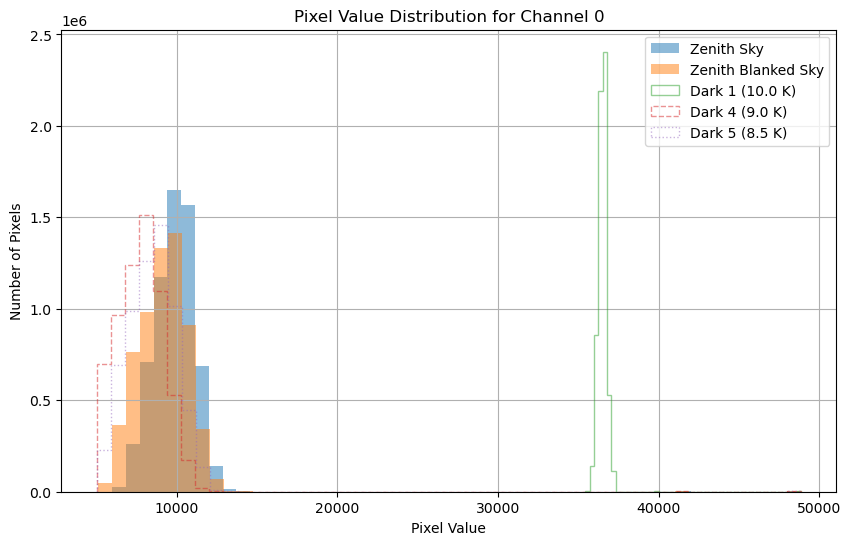

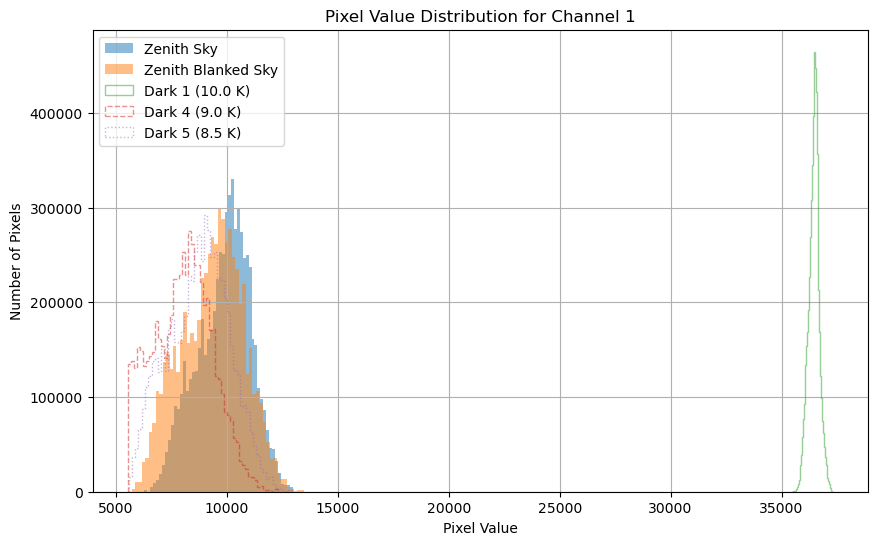

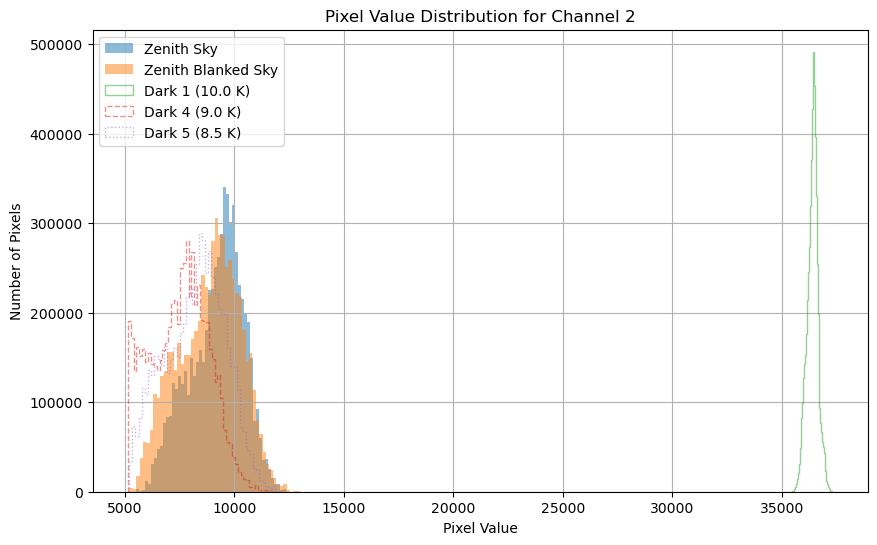

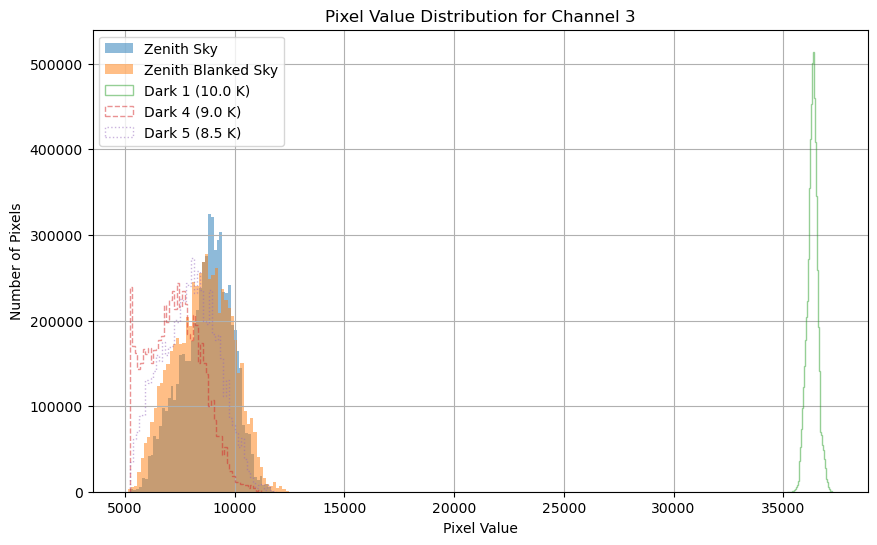

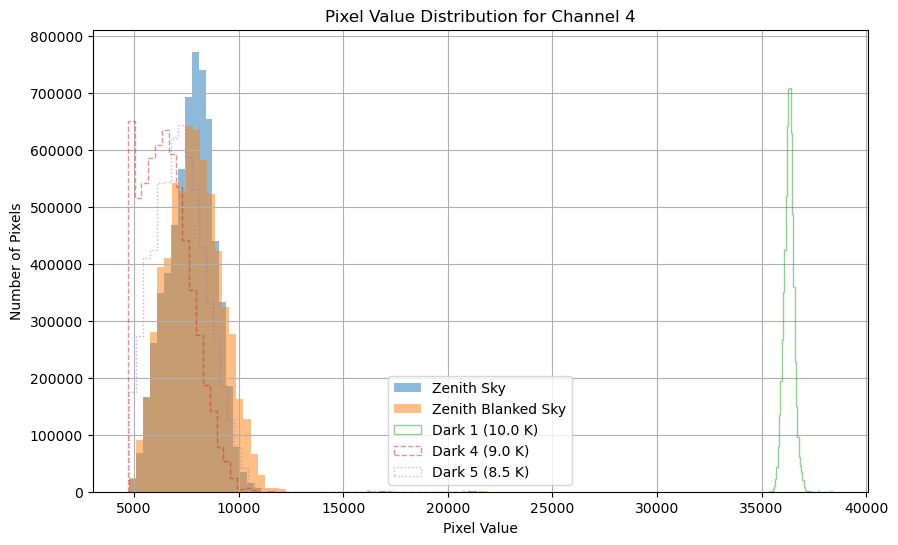

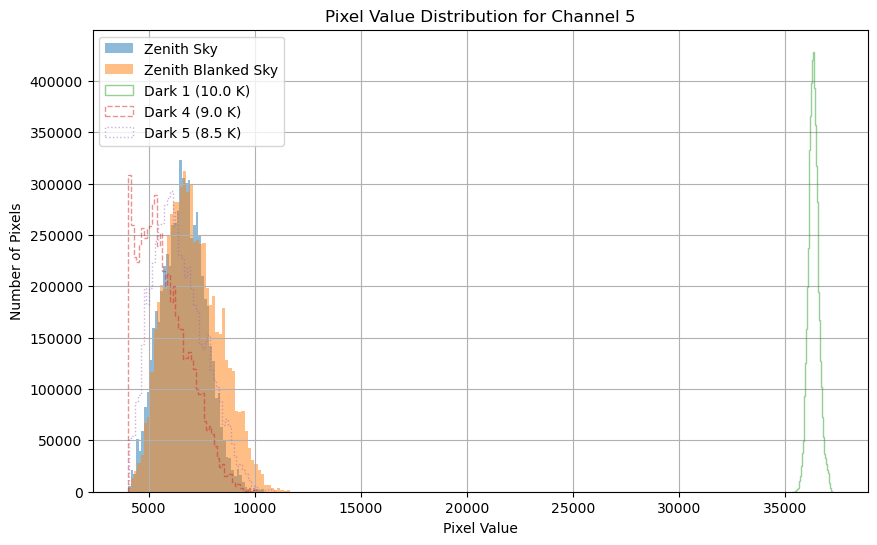

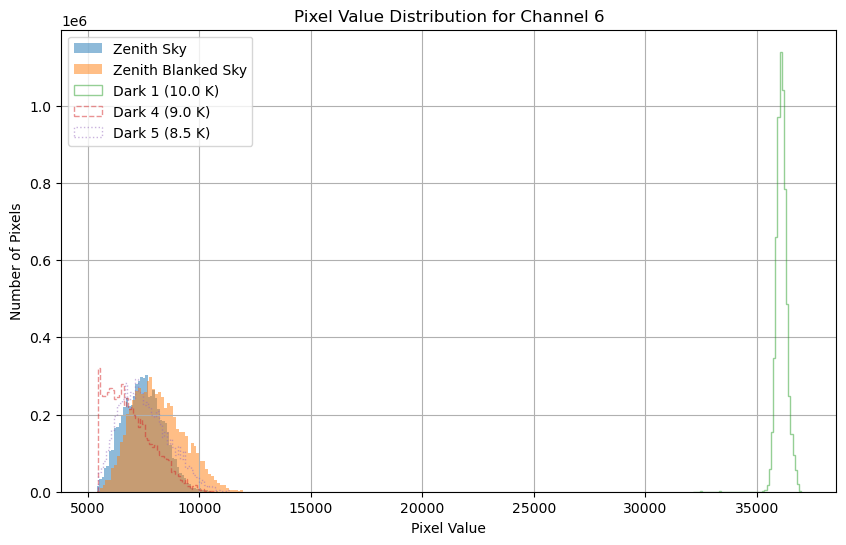

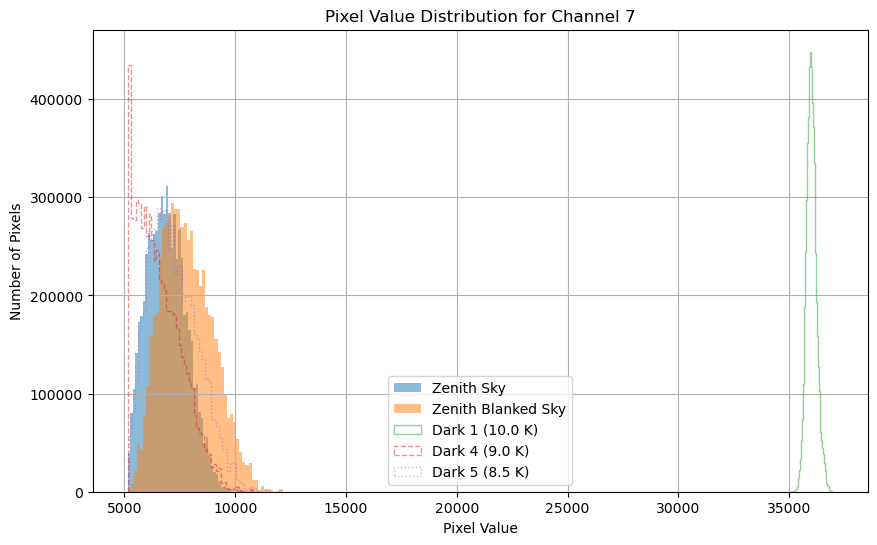

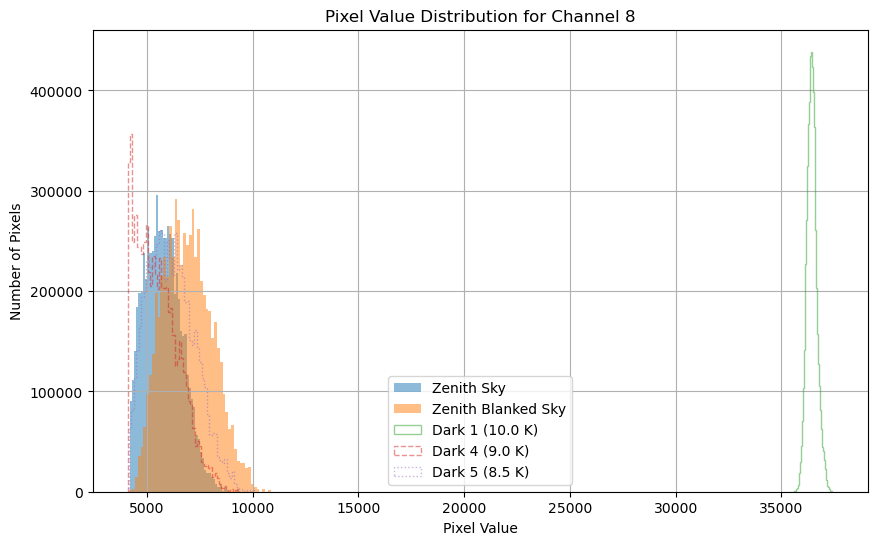

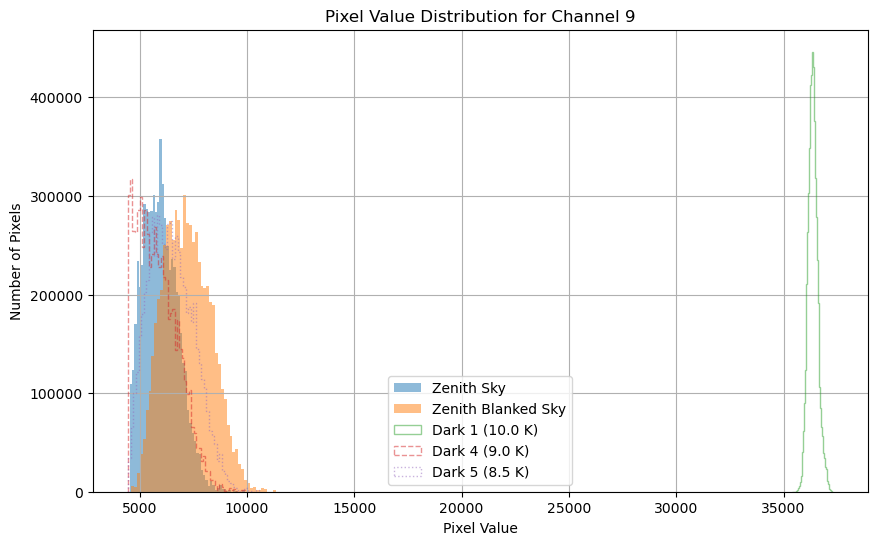

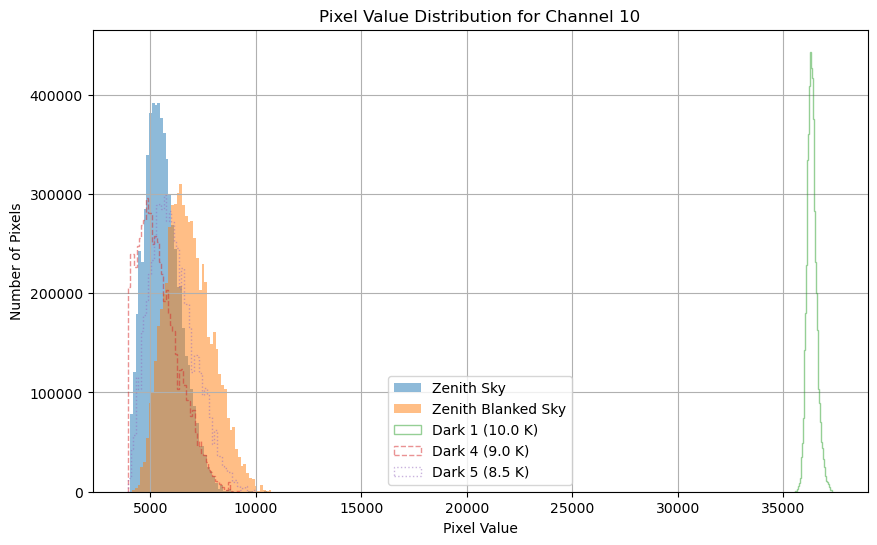

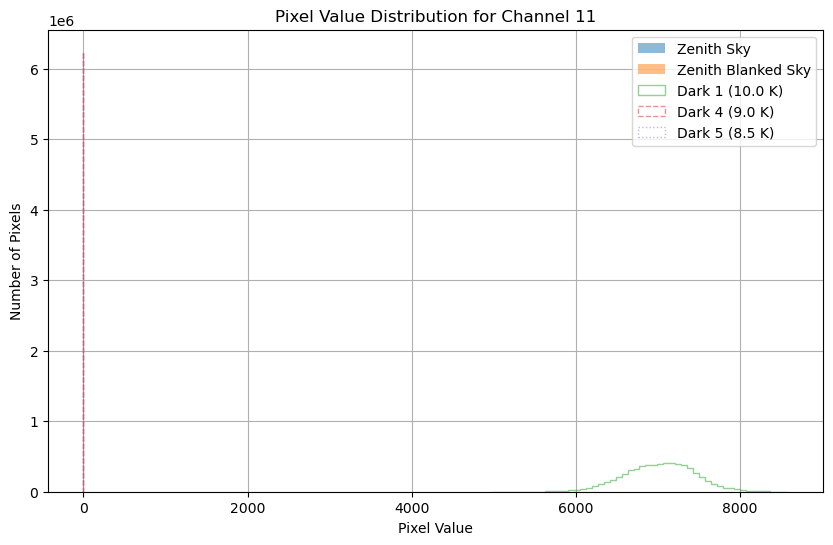

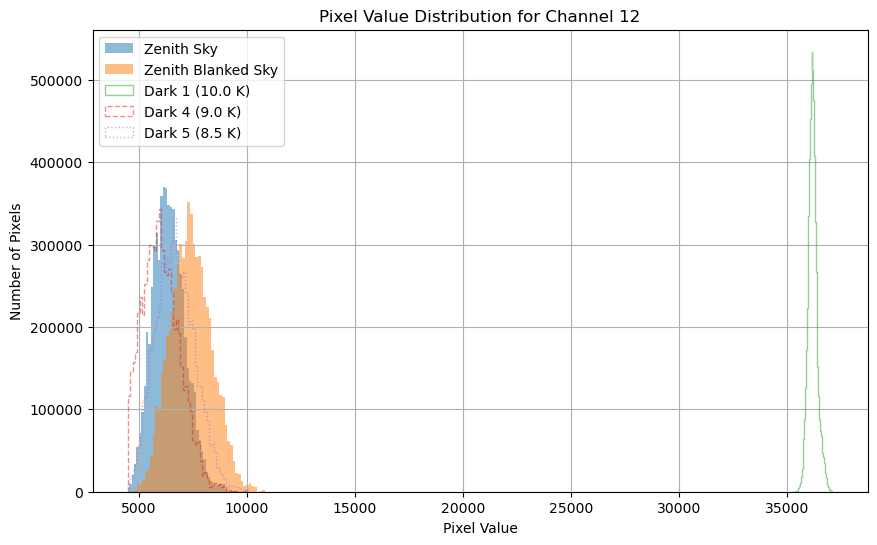

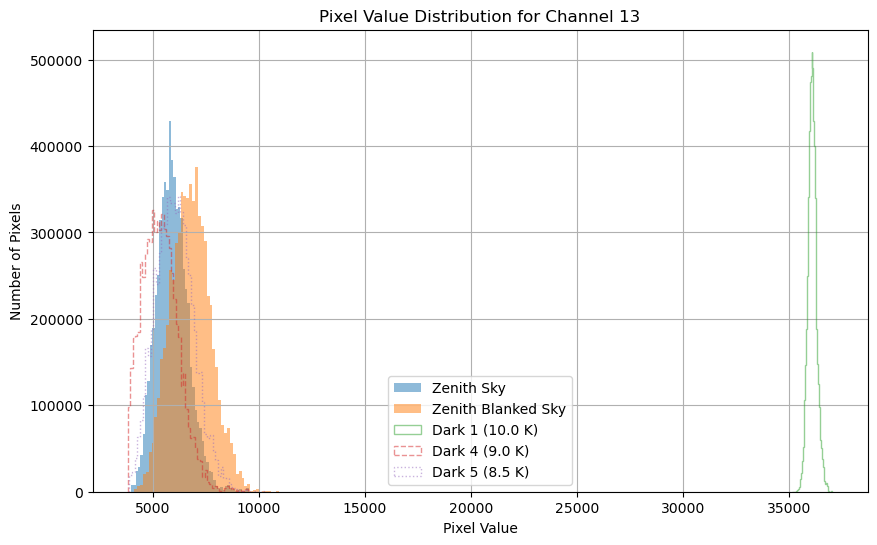

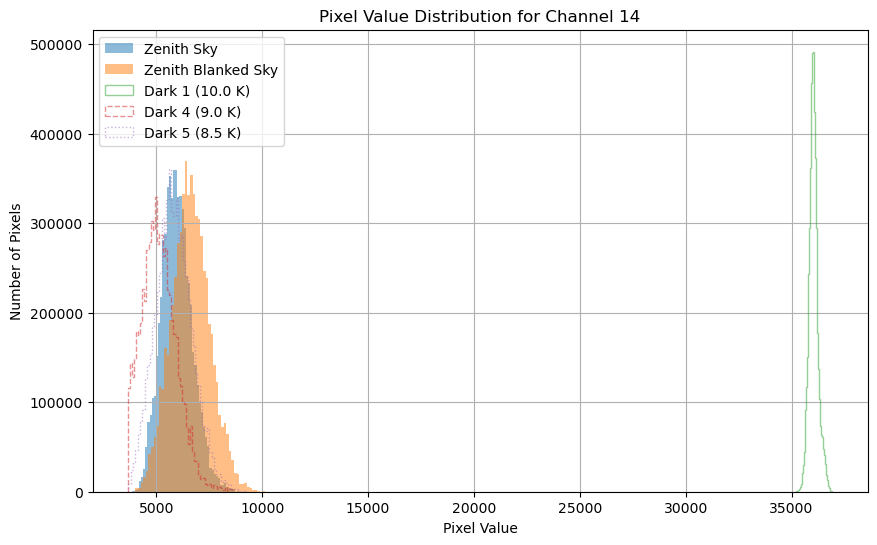

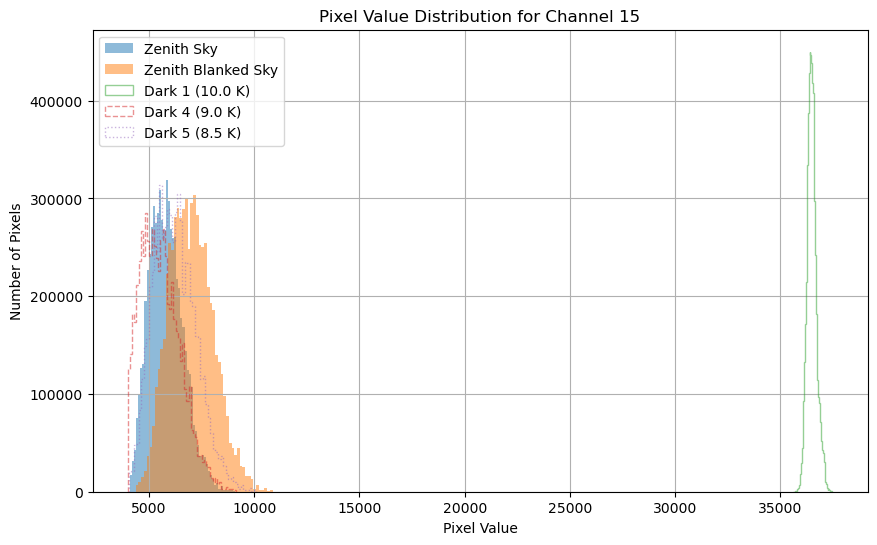

In [16]:
# Loop through the columns and make a histogram of the pixel values 
for channel in range(zenith_sky_data_channels["channels"].shape[0]):
    plt.figure(figsize=(10, 6))
    pixel_values_sky = zenith_sky_data_channels["channels"][channel].flatten()
    pixel_values_blanked = zenith_blanked_sky_data_channels["channels"][channel].flatten()
    pixel_values_dark1 = dark_1_data_channels["channels"][channel].flatten()
    pixel_values_dark4 = dark_4_data_channels["channels"][channel].flatten()
    pixel_values_dark5 = dark_5_data_channels["channels"][channel].flatten()
    
    plt.hist(pixel_values_sky, bins=50, alpha=0.5, label='Zenith Sky')
    plt.hist(pixel_values_blanked, bins=50, alpha=0.5, label='Zenith Blanked Sky')
    plt.hist(pixel_values_dark1, bins=50, alpha=0.5, label='Dark 1 (10.0 K)', histtype='step', linestyle='-')
    plt.hist(pixel_values_dark4, bins=50, alpha=0.5, label='Dark 4 (9.0 K)', histtype='step', linestyle='--')
    plt.hist(pixel_values_dark5, bins=50, alpha=0.5, label='Dark 5 (8.5 K)', histtype='step', linestyle=':')
    
    plt.xlabel('Pixel Value')
    plt.ylabel('Number of Pixels')
    plt.title(f'Pixel Value Distribution for Channel {channel}')
    plt.legend()
    plt.grid()
    plt.show()


Pretty convincing signs for a light leak present in MIRSI. Will need to see about the other data first.

## Estimation of leak contributions

Here, we can estimate the contribution of the light leak by taking the difference in the peaks from the two functions. Here, it stands to reason that the leak is contributing most of the flux (as evidenced by the counts and the fact that the blanked ones also hav ethe bend to them - indicating some temporal variability). One wouldn't expect this with a leak. 

In [17]:
zenith_sky_values = []
zenith_blanked_sky_values = []
dark_1_values = []

# It seems like channels 12, 13, 14, and 15 are all fairly well behaved so we'll analyze those channels in more detail.
for channel in range(12, 16):
    zenith_sky_values.append(zenith_sky_data_channels["channels"][channel].flatten())
    zenith_blanked_sky_values.append(zenith_blanked_sky_data_channels["channels"][channel].flatten())
    dark_1_values.append(dark_1_data_channels["channels"][channel].flatten())

In [18]:
# Find the average of the zenith sky, blanked sky, and dark 1 pixel values for channels 12-15 to see if the zenith sky has a higher average pixel value than the blanked sky and dark data sets.
avg_pixel_value_sky = np.mean(zenith_sky_values)
avg_pixel_value_blanked = np.mean(zenith_blanked_sky_values)
avg_pixel_value_dark1 = np.mean(dark_1_values)
print(f'Average Pixel Value for Zenith Sky: {avg_pixel_value_sky}')
print(f'Average Pixel Value for Zenith Blanked Sky: {avg_pixel_value_blanked}')
print(f'Average Pixel Value for Dark 1 (10.0 K): {avg_pixel_value_dark1}')

Average Pixel Value for Zenith Sky: 6028.890866105769
Average Pixel Value for Zenith Blanked Sky: 6954.900810416667
Average Pixel Value for Dark 1 (10.0 K): 36188.49678669872


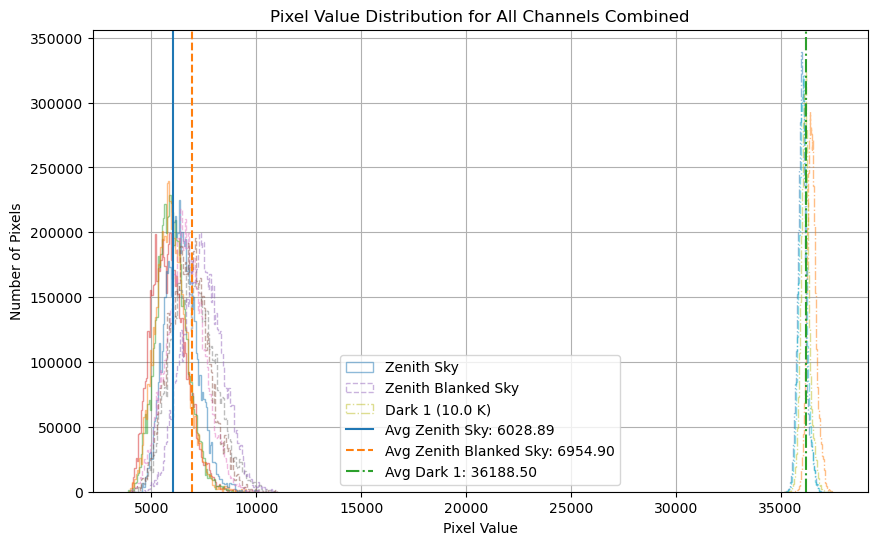

In [21]:
# Make a histogram of the pixel values for all channels combined
plt.figure(figsize=(10, 6))
plt.hist(zenith_sky_values, bins=100, alpha=0.5, label='Zenith Sky', histtype='step', linestyle='-')
plt.hist(zenith_blanked_sky_values, bins=100, alpha=0.5, label='Zenith Blanked Sky', histtype='step', linestyle='--')
plt.hist(dark_1_values, bins=100, alpha=0.5, label='Dark 1 (10.0 K)', histtype='step', linestyle='-.')
plt.axvline(avg_pixel_value_sky, color='C0', linestyle='-', label=f'Avg Zenith Sky: {avg_pixel_value_sky:.2f}')
plt.axvline(avg_pixel_value_blanked, color='C1', linestyle='--', label=f'Avg Zenith Blanked Sky: {avg_pixel_value_blanked:.2f}')
plt.axvline(avg_pixel_value_dark1, color='C2', linestyle='-.', label=f'Avg Dark 1: {avg_pixel_value_dark1:.2f}')
plt.xlabel('Pixel Value')
plt.ylabel('Number of Pixels')
plt.title('Pixel Value Distribution for All Channels Combined')
plt.legend()
plt.grid()
plt.show()

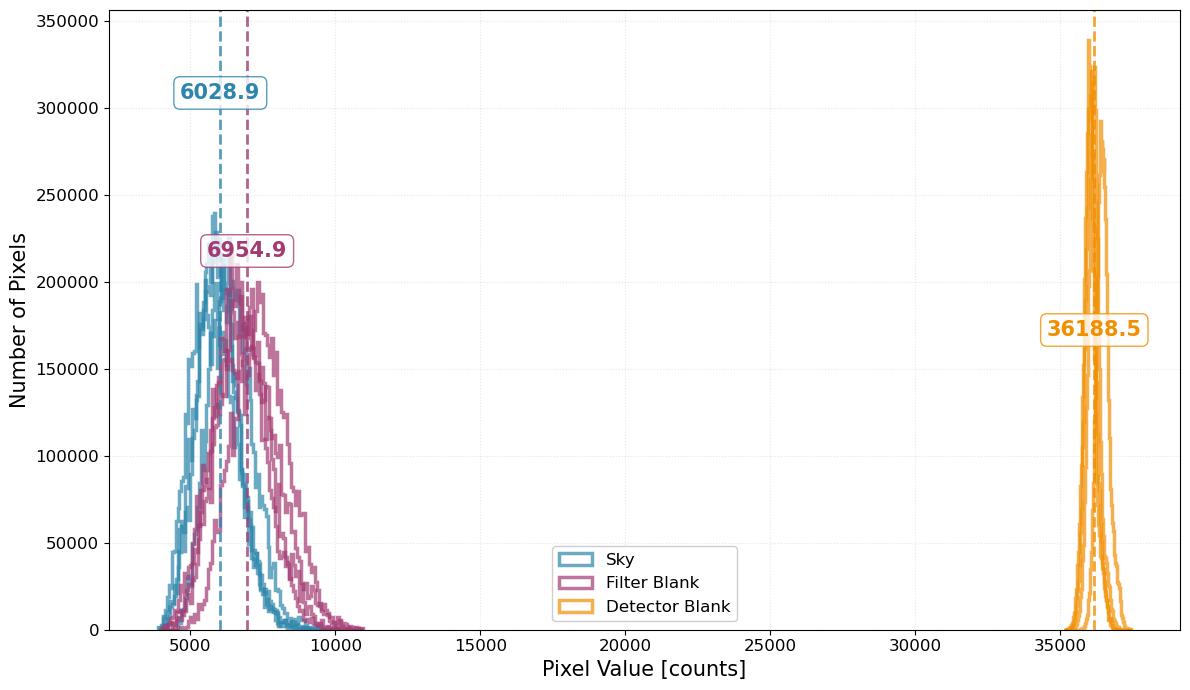

In [ ]:
# Make a histogram of the pixel values for all channels combined
plt.figure(figsize=(12, 7))

# Define distinct colors for clarity
color_sky = '#2E86AB'       # Blue
color_blanked = '#A23B72'   # Purple  
color_dark = '#F18F01'      # Orange

plt.hist(zenith_sky_values, bins=100, alpha=0.7, label='Sky', 
         histtype='step', linewidth=2.5, edgecolor=color_sky)
plt.hist(zenith_blanked_sky_values, bins=100, alpha=0.7, label='Filter Blank', 
         histtype='step', linewidth=2.5, edgecolor=color_blanked)
plt.hist(dark_1_values, bins=100, alpha=0.7, label='Detector Blank', 
         histtype='step', linewidth=2.5, edgecolor=color_dark)

# Add vertical lines for averages (without labels)
plt.axvline(avg_pixel_value_sky, color=color_sky, linestyle='--', linewidth=2, alpha=0.8)
plt.axvline(avg_pixel_value_blanked, color=color_blanked, linestyle='--', linewidth=2, alpha=0.8)
plt.axvline(avg_pixel_value_dark1, color=color_dark, linestyle='--', linewidth=2, alpha=0.8)

# Add text annotations next to the vertical lines
ylim = plt.ylim()
text_y = ylim[1] * 0.85  # Position text at 85% of y-axis height

plt.text(avg_pixel_value_sky, text_y, f'{avg_pixel_value_sky:.1f}', 
         color=color_sky, fontsize=15, fontweight='bold', 
         ha='center', va='bottom', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color_sky, alpha=0.8))
plt.text(avg_pixel_value_blanked, text_y * 0.7, f'{avg_pixel_value_blanked:.1f}', 
         color=color_blanked, fontsize=15, fontweight='bold', 
         ha='center', va='bottom', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color_blanked, alpha=0.8))
plt.text(avg_pixel_value_dark1, text_y * 0.55, f'{avg_pixel_value_dark1:.1f}', 
         color=color_dark, fontsize=15, fontweight='bold',
         ha='center', va='bottom', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color_dark, alpha=0.8))

plt.xlabel('Pixel Value [counts]', fontsize=15)
plt.ylabel('Number of Pixels', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12, framealpha=0.95, loc='best')
plt.grid(alpha=0.3, linestyle=':')
plt.tight_layout()

# Optional: save figuref
plt.savefig('./figures/pixel_value_distribution.png', dpi=600, bbox_inches='tight')
plt.show()

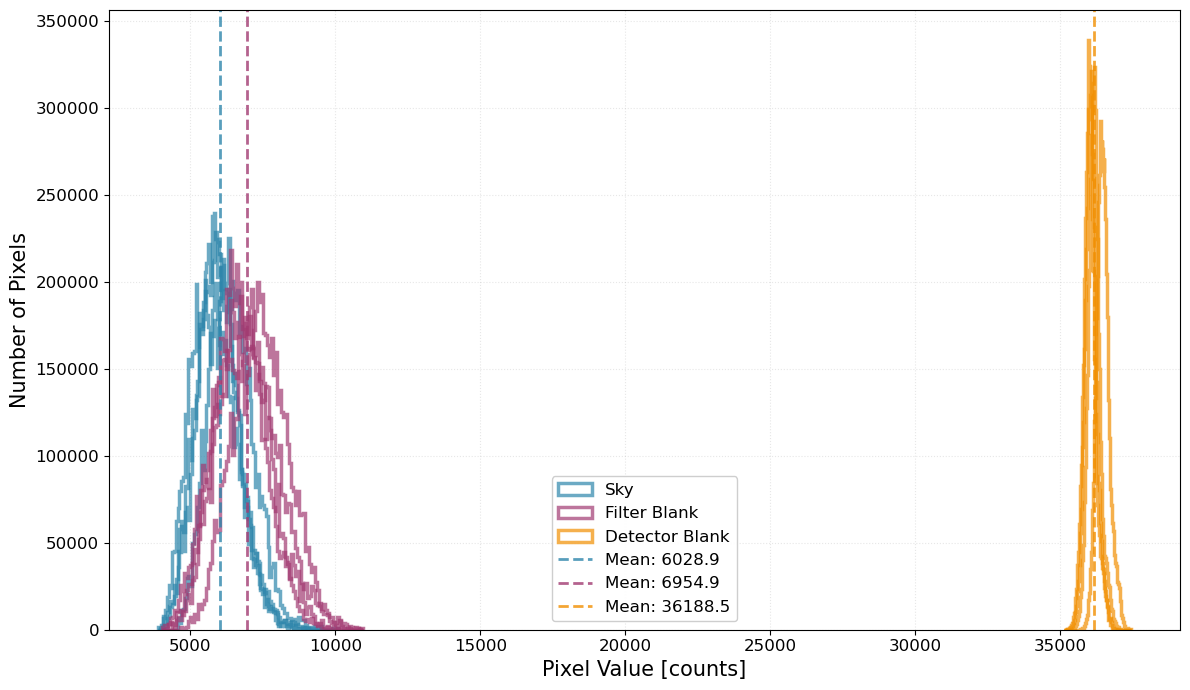

In [27]:
# Make a histogram of the pixel values for all channels combined
plt.figure(figsize=(12, 7))

# Define distinct colors for clarity
color_sky = '#2E86AB'       # Blue
color_blanked = '#A23B72'   # Purple  
color_dark = '#F18F01'      # Orange

plt.hist(zenith_sky_values, bins=100, alpha=0.7, label='Sky', 
         histtype='step', linewidth=2.5, edgecolor=color_sky)
plt.hist(zenith_blanked_sky_values, bins=100, alpha=0.7, label='Filter Blank',
         histtype='step', linewidth=2.5, edgecolor=color_blanked)
plt.hist(dark_1_values, bins=100, alpha=0.7, label='Detector Blank', 
         histtype='step', linewidth=2.5, edgecolor=color_dark)

# Add vertical lines for averages with matching colors
plt.axvline(avg_pixel_value_sky, color=color_sky, linestyle='--', linewidth=2, 
            alpha=0.8, label=f'Mean: {avg_pixel_value_sky:.1f}')
plt.axvline(avg_pixel_value_blanked, color=color_blanked, linestyle='--', linewidth=2, 
            alpha=0.8, label=f'Mean: {avg_pixel_value_blanked:.1f}')
plt.axvline(avg_pixel_value_dark1, color=color_dark, linestyle='--', linewidth=2, 
            alpha=0.8, label=f'Mean: {avg_pixel_value_dark1:.1f}')

plt.xlabel('Pixel Value [counts]', fontsize=15)
plt.ylabel('Number of Pixels', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12, framealpha=0.95)
plt.grid(alpha=0.3, linestyle=':')
plt.tight_layout()

# Optional: save figure
# plt.savefig('./figures/pixel_value_distribution.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# Assuming we are in the linear regime, find the contribution of the light leak by finding the difference between the average pixel value of the zenith sky and the average pixel value of the blanked sky and dark data sets.
sky_blanked_diff = np.abs(avg_pixel_value_sky - avg_pixel_value_blanked )
fractional_contribution = (avg_pixel_value_dark1 - avg_pixel_value_sky) / sky_blanked_diff
print(f'Fractional Contribution of Light Leak: {fractional_contribution:.2f}')

In [ ]:
print(f"approximate decrease in noise: {np.sqrt(fractional_contribution):.2f}")

So, the light leak is 32.6 times the regular sky? Does that seam right? Or it at least produces 32.6x the amount on the signal... so could getting rid of this light leak could result in an approximate signal to noise increase of about 5-6 times. 